In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns
%matplotlib inline

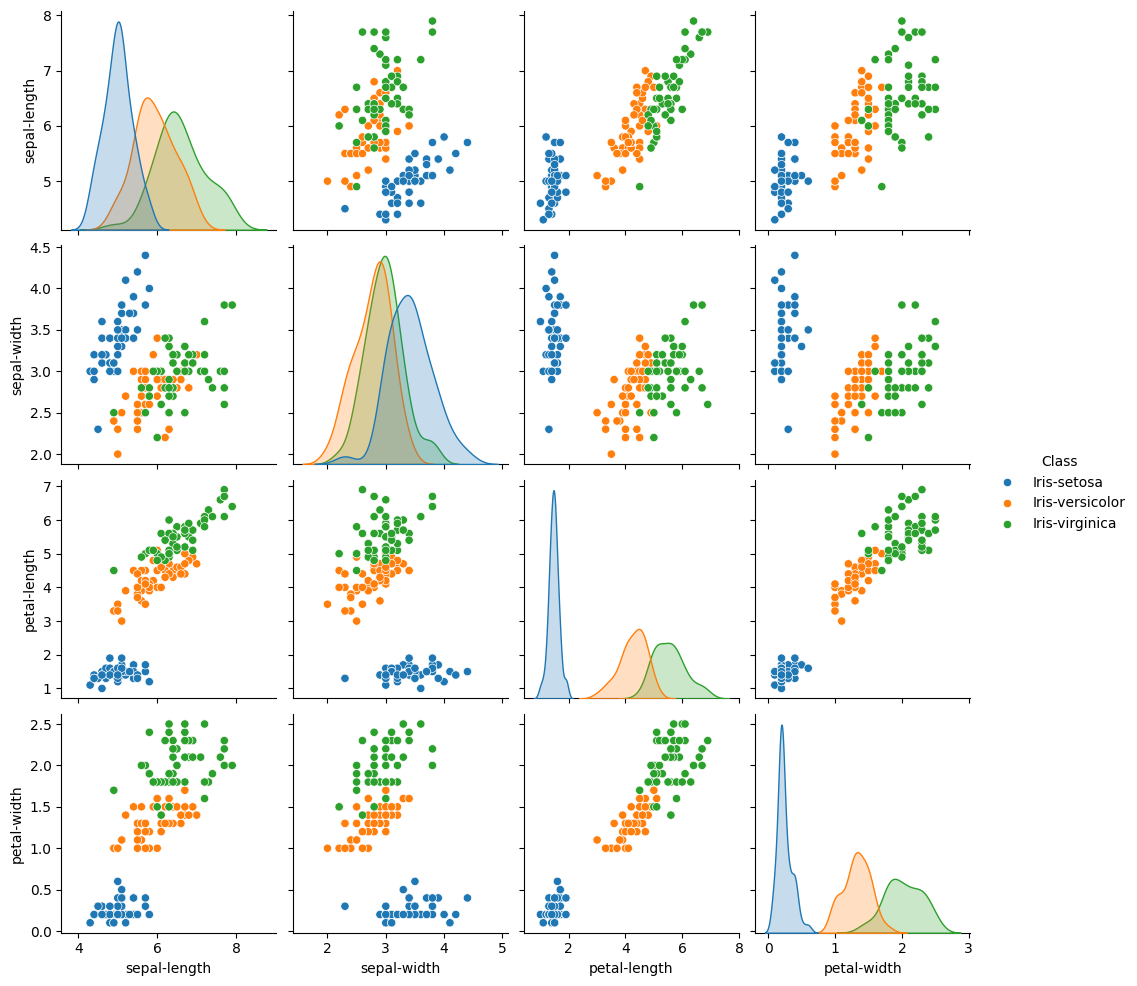

In [2]:
# Read the remote database directly from its url (Jupyter):
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# Assign colum names to the dataset
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
# Read dataset to pandas dataframe
dataset = pd.read_csv(url, names=names)
sns.pairplot(dataset, hue='Class') #A very cool plot to explore a dataset
# Notice that iris-setosa is easily identifiable by petal length and petal width, 
# while the other two species are much more difficult to distinguish.

In [3]:
dataset.tail()

,sepal-length,sepal-width,petal-length,petal-width,Class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.75)

In [6]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=123456)
rf.fit(X_train, y_train)
predicted = rf.predict(X_test)

In [7]:
myx = [[3	,3,	1,	2.5]]
rf.predict(myx)	

array(['Iris-setosa'], dtype=object)

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def summarize_rf_model(rf, X_train, y_train, X_test, y_test, predicted, probabilities=None):
    print("Random Forest Summary:")
    print(f"- OOB Score (if enabled): {getattr(rf, 'oob_score_', 'N/A')}")
    print(f"- Train Accuracy: {rf.score(X_train, y_train):.3f}")
    print(f"- Test Accuracy: {rf.score(X_test, y_test):.3f}")
    print(f"- Classes: {rf.classes_}")
    print(f"- Number of Features: {rf.n_features_in_}")
    
    print("\n Classification Report:")
    print(classification_report(y_test, predicted))

    print(" Confusion Matrix:")
    print(confusion_matrix(y_test, predicted))
    
    if probabilities is not None and rf.n_classes_ == 2:
        roc_auc = roc_auc_score(y_test, probabilities[:, 1])
        print(f"\n🔍 ROC AUC Score: {roc_auc:.3f}")


Random Forest Summary:
- OOB Score (if enabled): 0.9459459459459459
- Train Accuracy: 1.000
- Test Accuracy: 0.956
- Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
- Number of Features: 4

 Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        36
Iris-versicolor       0.95      0.93      0.94        41
 Iris-virginica       0.92      0.94      0.93        36

       accuracy                           0.96       113
      macro avg       0.96      0.96      0.96       113
   weighted avg       0.96      0.96      0.96       113

 Confusion Matrix:
[[36  0  0]
 [ 0 38  3]
 [ 0  2 34]]


<Axes: >

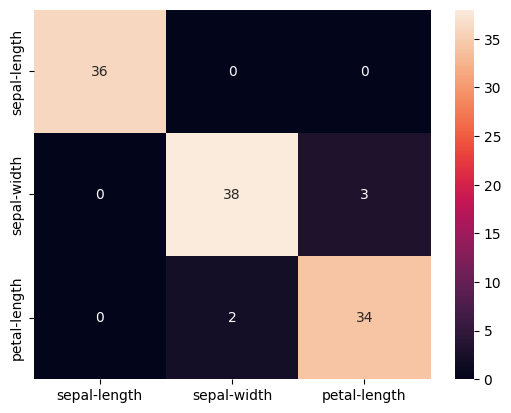

In [9]:
predicted = rf.predict(X_test)
probabilities = rf.predict_proba(X_test)
summarize_rf_model(rf, X_train, y_train, X_test, y_test, predicted, probabilities)
cm = pd.DataFrame(confusion_matrix(y_test, predicted), columns=names[0:3], index=names[0:3])
sns.heatmap(cm, annot=True)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_feature_importance(rf, feature_names, top_n=10):
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_importances)), top_importances[::-1], align='center')
    plt.yticks(range(len(top_importances)), top_features[::-1])
    plt.xlabel("Feature Importance")
    plt.title("Top Feature Importances from Random Forest")
    plt.tight_layout()
    plt.show()


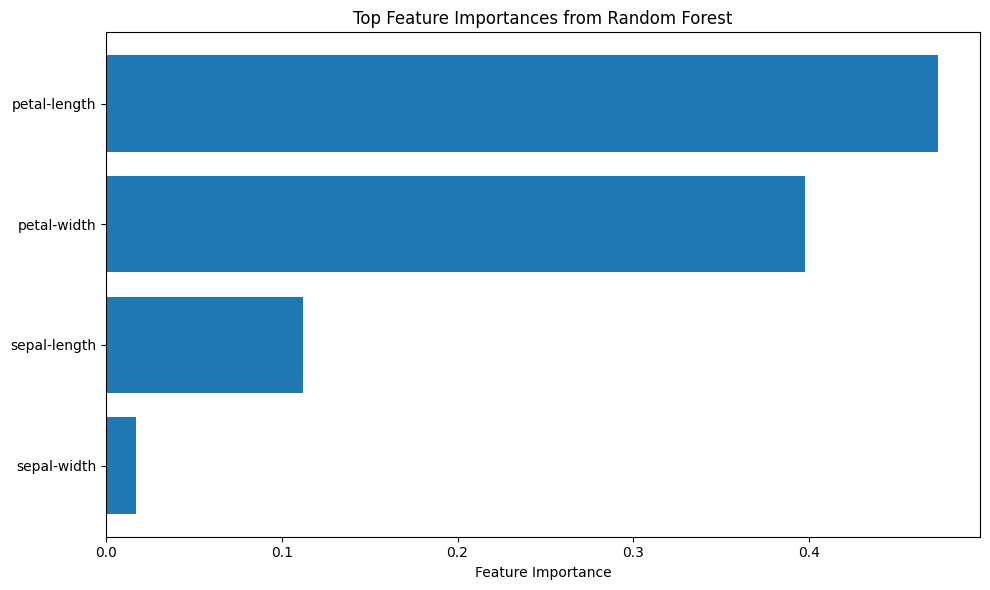

In [11]:
plot_feature_importance(rf, names, top_n=15)